
Class distribution (FULL DATASET)
Has_Anxiety
0    2795
1    8205
Name: count, dtype: int64

Class percentages:
Has_Anxiety
0    25.409091
1    74.590909
Name: count, dtype: float64

Class ratios (relative to minority class):
Class 0: 1.00 : 1
Class 1: 2.94 : 1

Training set distribution:
Has_Anxiety
0    2236
1    6564
Name: count, dtype: int64
Ratios:
Class 0: 1.00 : 1
Class 1: 2.94 : 1

Test set distribution:
Has_Anxiety
0     559
1    1641
Name: count, dtype: int64
Ratios:
Class 0: 1.00 : 1
Class 1: 2.94 : 1


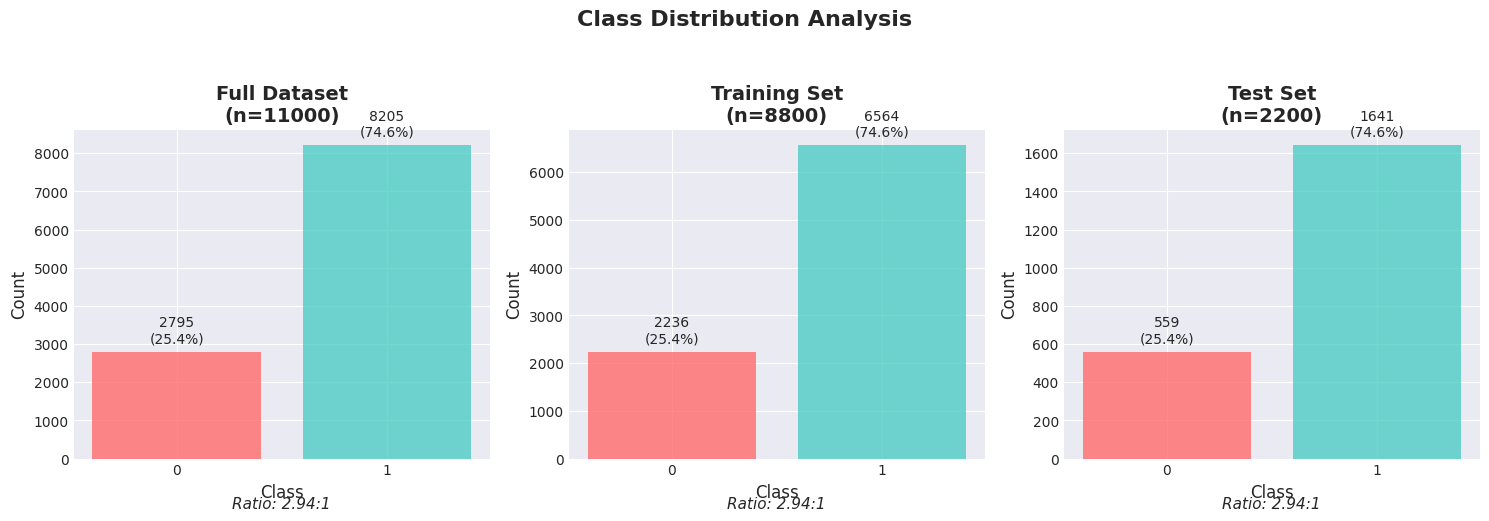


Computed class weights:
Class 0: 1.9678
Class 1: 0.6703

Optimal classification threshold: 0.5700

Model Performance
------------------
ROC-AUC : 0.8748
Accuracy: 0.7668
Log Loss: 0.4473

5-Fold CV ROC-AUC: 0.8841 ± 0.0030


/tmp/ipykernel_9435/3641996432.py:329: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


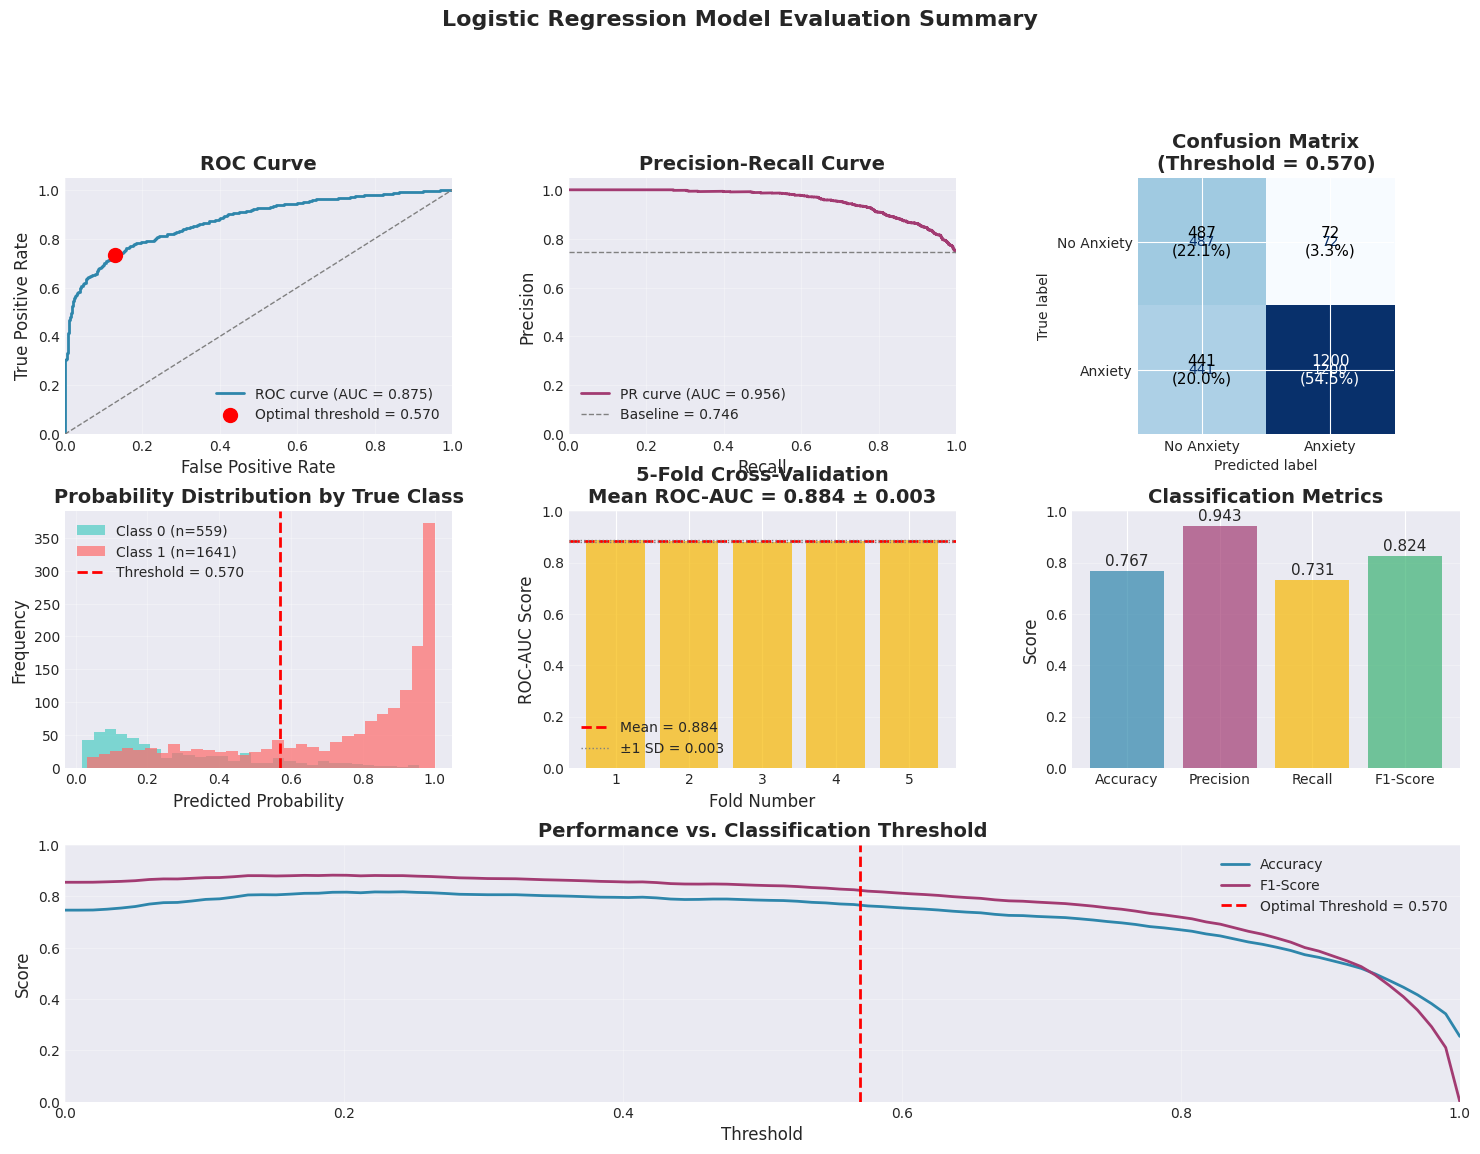


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Anxiety       0.52      0.87      0.66       559
     Anxiety       0.94      0.73      0.82      1641

    accuracy                           0.77      2200
   macro avg       0.73      0.80      0.74      2200
weighted avg       0.84      0.77      0.78      2200


Threshold Analysis:
Using threshold = 0.570
Accuracy: 0.767
F1-Score: 0.824


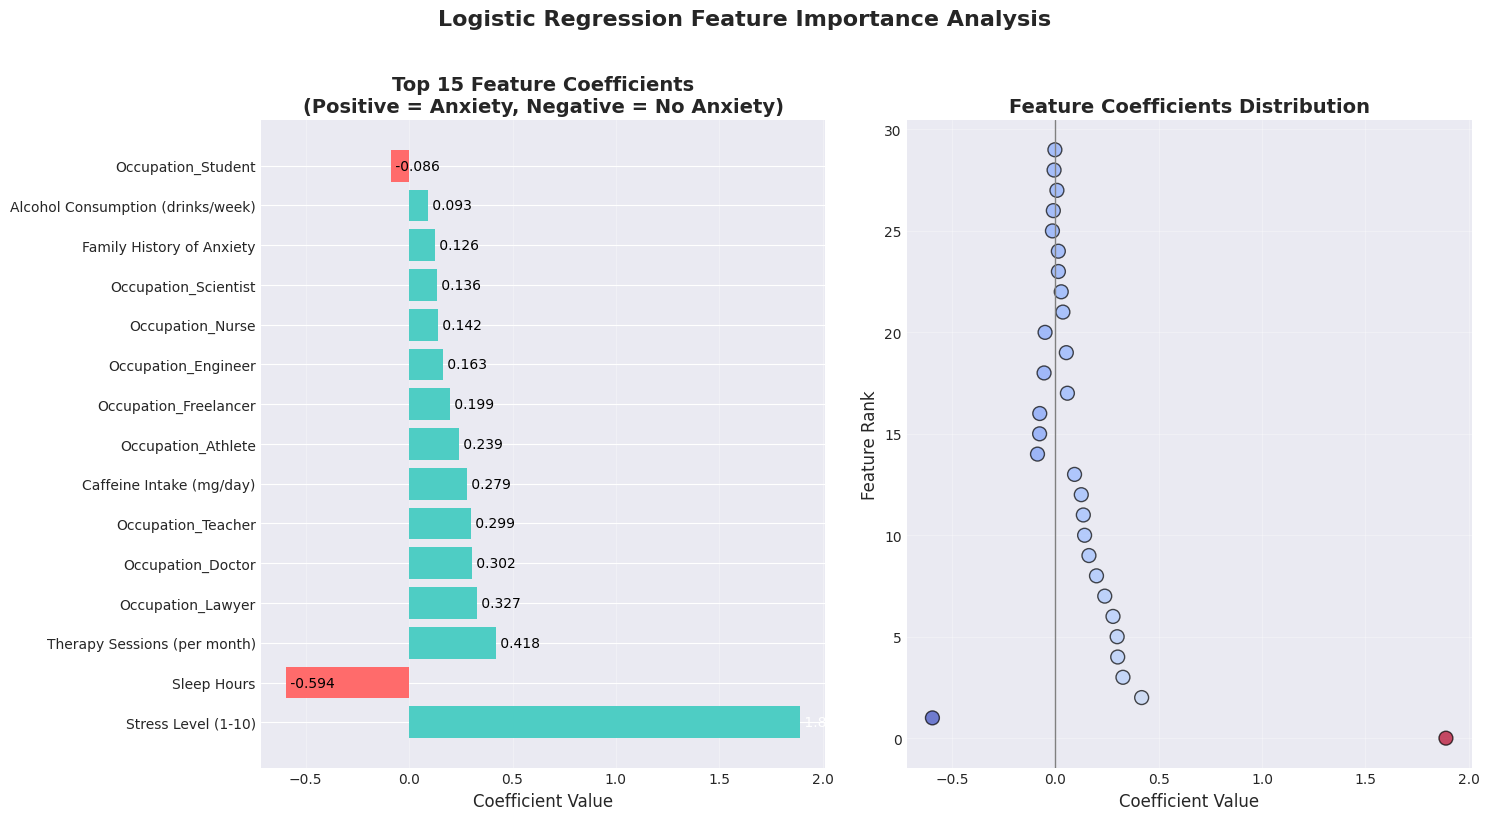


Top 10 Most Important Features:
                     Feature  Coefficient
         Stress Level (1-10)     1.889011
                 Sleep Hours    -0.593938
Therapy Sessions (per month)     0.417729
           Occupation_Lawyer     0.327306
           Occupation_Doctor     0.301946
          Occupation_Teacher     0.299366
    Caffeine Intake (mg/day)     0.279202
          Occupation_Athlete     0.239288
       Occupation_Freelancer     0.199388
         Occupation_Engineer     0.162881

MODEL EVALUATION COMPLETE


In [1]:
# --------------------------
# Binary Logistic Regression: Anxiety Prediction (NO SMOTE)
# --------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from matplotlib.gridspec import GridSpec

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, accuracy_score, log_loss,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, auc, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

# --------------------------
# 1. Load data
# --------------------------
data = pd.read_csv("clean.csv")

# --------------------------
# 2. Define binary target
# --------------------------
data["Has_Anxiety"] = (data["Anxiety Level (1-10)"] >= 3).astype(int)

X = data.drop(["Anxiety Level (1-10)", "Has_Anxiety"], axis=1)
y = data["Has_Anxiety"]

# --------------------------
# 3. Show class balance & ratio (FULL DATASET)
# --------------------------
counts = y.value_counts().sort_index()
ratios = counts / counts.min()

print("\nClass distribution (FULL DATASET)")
print(counts)

print("\nClass percentages:")
print((counts / counts.sum()) * 100)

print("\nClass ratios (relative to minority class):")
for cls in counts.index:
    print(f"Class {cls}: {ratios[cls]:.2f} : 1")

# --------------------------
# 4. Visualize Class Balance
# --------------------------
def plot_class_balance(y_train, y_test, y_full):
    """Plot class balance for full dataset, training set, and test set"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    datasets = [("Full Dataset", y_full), ("Training Set", y_train), ("Test Set", y_test)]
    colors = ['#FF6B6B', '#4ECDC4']
    
    for idx, (title, y_data) in enumerate(datasets):
        counts = y_data.value_counts().sort_index()
        percentages = (counts / counts.sum() * 100).round(1)
        
        # Bar plot
        bars = axes[idx].bar(counts.index.astype(str), counts.values, color=colors, alpha=0.8)
        axes[idx].set_title(f'{title}\n(n={len(y_data)})', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Class', fontsize=12)
        axes[idx].set_ylabel('Count', fontsize=12)
        
        # Add count labels on bars
        for bar, count, percent in zip(bars, counts.values, percentages):
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height + 0.02*max(counts),
                          f'{count}\n({percent}%)',
                          ha='center', va='bottom', fontsize=10)
        
        # Add ratio text
        ratio = counts.max() / counts.min() if counts.min() > 0 else np.inf
        axes[idx].text(0.5, -0.15, f'Ratio: {ratio:.2f}:1',
                      transform=axes[idx].transAxes,
                      ha='center', fontsize=11, style='italic')
    
    plt.suptitle('Class Distribution Analysis', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# --------------------------
# 5. Identify categorical & numeric columns
# --------------------------
cat_cols = ["Gender", "Occupation"]
num_cols = [c for c in X.columns if c not in cat_cols]

# --------------------------
# 6. Preprocessing
# --------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

# --------------------------
# 7. Train-test split
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

def print_split_stats(name, y_split):
    counts = y_split.value_counts().sort_index()
    ratios = counts / counts.min()
    print(f"\n{name} distribution:")
    print(counts)
    print("Ratios:")
    for cls in counts.index:
        print(f"Class {cls}: {ratios[cls]:.2f} : 1")

print_split_stats("Training set", y_train)
print_split_stats("Test set", y_test)

# Plot class balance visualization
plot_class_balance(y_train, y_test, y)


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print("\nComputed class weights:")
for cls, w in class_weight_dict.items():
    print(f"Class {cls}: {w:.4f}")


model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight=class_weight_dict,
        random_state=42
    ))
])

# --------------------------
# 10. Train model
# --------------------------
model.fit(X_train, y_train)

# --------------------------
# 11. Predict probabilities
# --------------------------
y_prob = model.predict_proba(X_test)[:, 1]

# --------------------------
# 12. Threshold tuning (Youden’s J)
# --------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
best_threshold = thresholds[np.argmax(tpr - fpr)]

print(f"\nOptimal classification threshold: {best_threshold:.4f}")

y_pred = (y_prob >= best_threshold).astype(int)

# --------------------------
# 13. Evaluation
# --------------------------
print("\nModel Performance")
print("------------------")
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Log Loss: {log_loss(y_test, y_prob):.4f}")

cv_scores = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print("\n5-Fold CV ROC-AUC: %.4f ± %.4f" % (cv_scores.mean(), cv_scores.std()))

# --------------------------
# 14. Comprehensive Model Evaluation Visualization
# --------------------------
def plot_model_evaluation(y_test, y_pred, y_prob, cv_scores, best_threshold):
    """Create comprehensive model evaluation plots"""
    
    # Create figure with GridSpec for better layout
    fig = plt.figure(figsize=(18, 12))
    gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    # 1. ROC Curve
    ax1 = fig.add_subplot(gs[0, 0])
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    ax1.plot(fpr, tpr, color='#2E86AB', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    ax1.scatter(fpr[np.argmax(tpr - fpr)], tpr[np.argmax(tpr - fpr)], 
                color='red', s=100, zorder=5, label=f'Optimal threshold = {best_threshold:.3f}')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate', fontsize=12)
    ax1.set_ylabel('True Positive Rate', fontsize=12)
    ax1.set_title('ROC Curve', fontsize=14, fontweight='bold')
    ax1.legend(loc="lower right")
    ax1.grid(True, alpha=0.3)
    
    # 2. Precision-Recall Curve
    ax2 = fig.add_subplot(gs[0, 1])
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    ax2.plot(recall, precision, color='#A23B72', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    baseline = len(y_test[y_test==1]) / len(y_test)
    ax2.axhline(y=baseline, color='gray', lw=1, linestyle='--', label=f'Baseline = {baseline:.3f}')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall', fontsize=12)
    ax2.set_ylabel('Precision', fontsize=12)
    ax2.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    ax2.legend(loc="lower left")
    ax2.grid(True, alpha=0.3)
    
    # 3. Confusion Matrix
    ax3 = fig.add_subplot(gs[0, 2])
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Anxiety', 'Anxiety'])
    disp.plot(ax=ax3, cmap='Blues', colorbar=False)
    ax3.set_title(f'Confusion Matrix\n(Threshold = {best_threshold:.3f})', fontsize=14, fontweight='bold')
    
    # Add text annotations with percentages
    total = cm.sum()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax3.text(j, i, f'{cm[i, j]}\n({cm[i, j]/total:.1%})',
                    ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black',
                    fontsize=11)
    
    # 4. Probability Distribution
    ax4 = fig.add_subplot(gs[1, 0])
    for label in [0, 1]:
        mask = y_test == label
        ax4.hist(y_prob[mask], bins=30, alpha=0.7, 
                label=f'Class {label} (n={sum(mask)})',
                color=['#4ECDC4', '#FF6B6B'][label])
    ax4.axvline(x=best_threshold, color='red', linestyle='--', lw=2, 
                label=f'Threshold = {best_threshold:.3f}')
    ax4.set_xlabel('Predicted Probability', fontsize=12)
    ax4.set_ylabel('Frequency', fontsize=12)
    ax4.set_title('Probability Distribution by True Class', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Cross-Validation Scores
    ax5 = fig.add_subplot(gs[1, 1])
    fold_numbers = np.arange(1, len(cv_scores) + 1)
    ax5.bar(fold_numbers, cv_scores, color='#F7B801', alpha=0.7)
    ax5.axhline(y=cv_scores.mean(), color='red', linestyle='--', lw=2, 
                label=f'Mean = {cv_scores.mean():.3f}')
    ax5.axhline(y=cv_scores.mean() + cv_scores.std(), color='gray', linestyle=':', lw=1)
    ax5.axhline(y=cv_scores.mean() - cv_scores.std(), color='gray', linestyle=':', lw=1,
                label=f'±1 SD = {cv_scores.std():.3f}')
    ax5.set_xlabel('Fold Number', fontsize=12)
    ax5.set_ylabel('ROC-AUC Score', fontsize=12)
    ax5.set_title(f'5-Fold Cross-Validation\nMean ROC-AUC = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}', 
                  fontsize=14, fontweight='bold')
    ax5.set_xticks(fold_numbers)
    ax5.set_ylim([0, 1.0])
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')
    
    # 6. Performance Metrics Bar Chart
    ax6 = fig.add_subplot(gs[1, 2])
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    # Calculate metrics
    from sklearn.metrics import precision_score, recall_score, f1_score
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    metric_values = [accuracy, precision, recall, f1]
    colors_metrics = ['#2E86AB', '#A23B72', '#F7B801', '#3BB273']
    
    bars = ax6.bar(metrics, metric_values, color=colors_metrics, alpha=0.7)
    ax6.set_ylabel('Score', fontsize=12)
    ax6.set_title('Classification Metrics', fontsize=14, fontweight='bold')
    ax6.set_ylim([0, 1.0])
    ax6.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, metric_values):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontsize=11)
    
    # 7. Threshold Analysis
    ax7 = fig.add_subplot(gs[2, :])
    thresholds = np.linspace(0, 1, 100)
    accuracy_scores = []
    f1_scores = []
    
    for thresh in thresholds:
        y_pred_temp = (y_prob >= thresh).astype(int)
        accuracy_scores.append(accuracy_score(y_test, y_pred_temp))
        f1_scores.append(f1_score(y_test, y_pred_temp))
    
    ax7.plot(thresholds, accuracy_scores, label='Accuracy', color='#2E86AB', lw=2)
    ax7.plot(thresholds, f1_scores, label='F1-Score', color='#A23B72', lw=2)
    ax7.axvline(x=best_threshold, color='red', linestyle='--', lw=2, 
                label=f'Optimal Threshold = {best_threshold:.3f}')
    ax7.set_xlabel('Threshold', fontsize=12)
    ax7.set_ylabel('Score', fontsize=12)
    ax7.set_title('Performance vs. Classification Threshold', fontsize=14, fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    ax7.set_xlim([0, 1])
    ax7.set_ylim([0, 1])
    
    plt.suptitle('Logistic Regression Model Evaluation Summary', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print detailed classification report
    print("\n" + "="*60)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=['No Anxiety', 'Anxiety']))
    
    # Print threshold analysis
    print(f"\nThreshold Analysis:")
    print(f"Using threshold = {best_threshold:.3f}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.3f}")

# Plot all evaluation graphs
plot_model_evaluation(y_test, y_pred, y_prob, cv_scores, best_threshold)

# --------------------------
# 15. Feature Importance (for logistic regression)
# --------------------------
def plot_feature_importance(model, X_train):
    """Plot feature importance for logistic regression"""
    # Extract feature names after preprocessing
    preprocessor = model.named_steps['preprocess']
    feature_names = []
    
    # Get numeric feature names
    feature_names.extend(num_cols)
    
    # Get categorical feature names
    encoder = preprocessor.named_transformers_['cat']
    cat_feature_names = encoder.get_feature_names_out(cat_cols)
    feature_names.extend(cat_feature_names)
    
    # Get coefficients from the logistic regression model
    coefficients = model.named_steps['clf'].coef_[0]
    
    # Create DataFrame for feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
        'Abs_Coefficient': np.abs(coefficients)
    })
    
    # Sort by absolute coefficient value
    feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)
    
    # Plot top 15 features
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
    
    # Bar plot of coefficients
    top_features = feature_importance.head(15)
    colors = ['#4ECDC4' if x > 0 else '#FF6B6B' for x in top_features['Coefficient']]
    y_pos = np.arange(len(top_features))
    
    ax1.barh(y_pos, top_features['Coefficient'], color=colors)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(top_features['Feature'])
    ax1.set_xlabel('Coefficient Value', fontsize=12)
    ax1.set_title('Top 15 Feature Coefficients\n(Positive = Anxiety, Negative = No Anxiety)', 
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, v in enumerate(top_features['Coefficient']):
        ax1.text(v, i, f' {v:.3f}', va='center', fontsize=10,
                color='black' if abs(v) < max(abs(top_features['Coefficient'])) * 0.5 else 'white')
    
    # Dot plot of all coefficients
    ax2.scatter(feature_importance['Coefficient'], range(len(feature_importance)),
               c=feature_importance['Coefficient'], cmap='coolwarm', 
               alpha=0.7, s=100, edgecolors='black')
    ax2.axvline(x=0, color='gray', linestyle='-', lw=1)
    ax2.set_xlabel('Coefficient Value', fontsize=12)
    ax2.set_ylabel('Feature Rank', fontsize=12)
    ax2.set_title('Feature Coefficients Distribution', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Logistic Regression Feature Importance Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return feature_importance

# Plot feature importance
try:
    feature_importance_df = plot_feature_importance(model, X_train)
    print("\nTop 10 Most Important Features:")
    print(feature_importance_df[['Feature', 'Coefficient']].head(10).to_string(index=False))
except Exception as e:
    print(f"\nNote: Could not plot feature importance. Error: {e}")

# --------------------------
# 16. Save the model (optional)
# --------------------------
# Uncomment to save the model
# joblib.dump(model, 'logistic_regression_model.pkl')
# print("\nModel saved as 'logistic_regression_model.pkl'")

print("\n" + "="*60)
print("MODEL EVALUATION COMPLETE")
print("="*60)